# 勇者傳說 — Buildings V3 + Decorations V4 Re-generator (T4 GPU)

**Visual-quality-driven** re-generation of failed buildings and decorations.

## Root cause from V2
- Background removal (RMBG-2.0) is too aggressive on **light-colored buildings** (stone, white walls)
- V2 quality thresholds were too lenient — passed visually empty/washed-out images

## V3 Key improvements
- **Hardened prompts**: Emphasize dark/opaque materials, strong outlines, saturated colors
- **Higher resolution**: 512×512 for all failed items (was 256-384)
- **More steps**: 30 steps, guidance 8.5 (was 25, 7.5)
- **Lower LoRA weight** for gates (0.5): Less stylization = more structural coherence
- **Stricter QC**: min_opaque 25% for gates, 20% for churches (was 15%, 10%)
- **Colored background trick**: Generate on dark green bg, then remove — prevents white-on-white loss

## Items to re-generate
### Buildings (16 items)
- **Gates**: hero, demon, dwarf, elf, giant, hotspring, merfolk, mountain, undead, volcano (10/12)
- **Churches**: hero, beast, undead (3/12)
- **Inn**: hotspring (1/12)
- **House**: merfolk (1/12)
- **Generic**: bld_inn (1/8)

### Decorations (2 items)
- **deco_dock**: V3 failed (2.7% opaque) — wooden pier blended with bg
- **deco_lava_vent**: V3 failed (5.5% opaque) — steam/gas too transparent

**Self-contained**: No repo clone needed.  
**Output**: Google Drive `/MyDrive/ai-rpg-game/outputs/`  
**Resume**: 中斷後重跑自動跳過已完成的

In [1]:
!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, os, time
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')
MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import torch
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
    DEVICE = 'cuda'
    DTYPE = torch.float16
    print(f'GPU: {name} ({vram:.1f} GB VRAM)')
else:
    DEVICE = 'cpu'
    DTYPE = torch.bfloat16
    print('WARNING: No GPU!')

print(f'Output: {OUTPUT_BASE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 44.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but y

In [2]:
from PIL import Image
import numpy as np


class ProgressTracker:
    def __init__(self, task_name, output_dir):
        self.file = Path(output_dir) / f'_progress_{task_name}.json'
        self.completed = set()
        self.start_time = time.time()
        if self.file.exists():
            try:
                data = json.loads(self.file.read_text())
                self.completed = set(data.get('completed', []))
                print(f'[resume] {len(self.completed)} items already done')
            except Exception:
                pass

    def is_done(self, name): return name in self.completed

    def mark_done(self, name):
        self.completed.add(name)
        self.file.parent.mkdir(parents=True, exist_ok=True)
        self.file.write_text(json.dumps({
            'completed': sorted(self.completed),
            'count': len(self.completed),
            'last_updated': time.strftime('%Y-%m-%d %H:%M:%S'),
        }, indent=2))


def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def print_vram():
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated(0) / 1024**3
        props = torch.cuda.get_device_properties(0)
        total = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
        print(f'[vram] {used:.1f}/{total:.1f} GB')


_rmbg_model = None
_rembg_session = None


def remove_background(img):
    """Remove background: RMBG-2.0 primary, rembg fallback."""
    global _rmbg_model, _rembg_session
    try:
        if _rmbg_model is None:
            from transformers import pipeline
            _rmbg_model = pipeline('image-segmentation',
                                   model='briaai/RMBG-2.0',
                                   trust_remote_code=True,
                                   device=0 if torch.cuda.is_available() else -1)
        result = _rmbg_model(img)
        mask = result[0]['mask'] if isinstance(result, list) else result['mask']
        img = img.convert('RGBA')
        img.putalpha(mask.convert('L'))
        return img
    except Exception as e:
        print(f'[warn] RMBG-2.0 failed: {e}, trying rembg...')
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(img, session=_rembg_session)
    except Exception as e:
        print(f'[warn] rembg failed: {e}')
        return img


def quality_check(img, min_opaque=0.15):
    """Check image quality: enough opaque pixels."""
    arr = np.array(img.convert('RGBA'))
    alpha = arr[:, :, 3]
    total = alpha.size
    opaque_pct = float(np.sum(alpha > 10) / total)
    return opaque_pct >= min_opaque, opaque_pct

In [3]:
# ─── V3 Hardened Prompts ───
# Root cause: bg removal kills light-colored buildings.
# Fix: Emphasize DARK colors, strong outlines, saturated materials.
# Also: higher gen resolution (512), more steps (30), higher guidance (8.5).

META = {
    'style_prefix': '16-bit JRPG pixel art, top-down RPG building sprite',
    'style_suffix': 'front view, single structure centered on dark green background, clean edges, detailed pixel art, strong black outlines, saturated colors',
    'negative': 'blurry, modern, multiple buildings, text, UI, photograph, realistic photo, people, characters, watermark, white background, faded, washed out, pale, transparent',
}

# V3 targets: visually verified failures from V2 output
V3_ENTRIES = [
    # ─── GATES (10/12 failed — all washed out except beast + treant) ───
    # V2 problem: stone/light gates become invisible after bg removal.
    # V3 fix: dark materials, iron/bronze/obsidian, strong color contrast.
    {'name': 'bld_gate_r1',  'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'medieval stone gatehouse archway with heavy iron portcullis, dark grey granite walls, blue banner flags, iron-bound oak doors, thick stone pillars with torches',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r2',  'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'elven forest gate archway made of dark living wood and thick vines, golden leaf decorations, green moss covered, heavy wooden doors, large tree trunk pillars',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r5',  'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'coral reef gate archway with massive blue-purple coral pillars, giant clamshell doors, seashell decorations, dark teal ocean stone walls, pearl accents, aquatic kingdom entrance',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r6',  'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'massive stone fortress gate with oversized dark granite blocks, heavy iron rivets, enormous stone archway, thick iron chains, imposing entrance',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r7',  'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'dwarven underground forge gate with dark carved stone pillars, glowing orange forge light, copper and bronze trim, heavy iron doors with anvil motifs, warm ember glow',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r8',  'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'gothic dark castle gate with cracked dark purple stone pillars, gargoyle statues, eerie green glowing runes, iron spikes, cobweb covered archway, haunted entrance',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r9',  'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'volcanic obsidian gate archway with black basalt pillars, bright orange lava cracks, fire motifs carved in dark stone, ember glow, magma veins in walls',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r10', 'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'Japanese torii gate with thick dark red wooden pillars, black curved roof tiles, hanging paper lanterns, bamboo fence sides, traditional onsen entrance gate',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r11', 'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'alpine mountain lodge gate with dark heavy timber frame, stone base, snow on top, colorful prayer flags, warm lantern light, rustic mountain pass entrance',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},
    {'name': 'bld_gate_r12', 'type': 'gate', 'min_opaque': 0.25,
     'prompt': 'demonic fortress gate with dark iron spike pillars, skull motifs, red glowing runes, bone decorations, dark stone archway with demon carvings, hellfire glow',
     'gen_size': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.5},

    # ─── CHURCHES (3 failed — washed out light stone) ───
    {'name': 'bld_church_r1',  'type': 'church', 'min_opaque': 0.20,
     'prompt': 'medieval stone church with tall dark grey bell tower, gold cross on top, stained glass windows glowing warm colors, heavy oak doors, dark slate roof, solid stone walls',
     'gen_size': 512, 'final_w': 128, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.7},
    {'name': 'bld_church_r4',  'type': 'church', 'min_opaque': 0.20,
     'prompt': 'tribal sacred temple with dark mud-brick walls, animal bone altar, thatched roof, hanging pelt decorations, warm firelight inside, totem poles flanking entrance',
     'gen_size': 512, 'final_w': 128, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.7},
    {'name': 'bld_church_r8',  'type': 'church', 'min_opaque': 0.20,
     'prompt': 'gothic dark chapel with cracked dark stone walls, purple stained glass, tall spire with skull ornament, eerie green candle glow, gargoyles, haunted cemetery church',
     'gen_size': 512, 'final_w': 128, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.7},

    # ─── INN (1 failed — hotspring nearly invisible) ───
    {'name': 'bld_inn_r10', 'type': 'inn', 'min_opaque': 0.20,
     'prompt': 'Japanese ryokan inn with dark wooden beams, curved dark tile roof, warm paper lantern glow, bamboo accents, sliding doors, noren curtain entrance, two-story wooden building',
     'gen_size': 512, 'final_w': 128, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.7},

    # ─── HOUSE (1 failed — merfolk sparse) ───
    {'name': 'bld_region_r5', 'type': 'house', 'min_opaque': 0.20,
     'prompt': 'coral reef house dwelling with dark blue-purple coral walls, large shell door, seaweed roof, glowing pearl windows, aquatic architecture, solid two-story structure',
     'gen_size': 512, 'final_w': 128, 'final_h': 128, 'steps': 30, 'guidance': 8.5, 'lora_w': 0.7},

    # ─── GENERIC (1 failed — bld_inn sparse) ───
    {'name': 'bld_inn', 'type': 'inn', 'min_opaque': 0.15,
     'prompt': 'cozy medieval inn tavern with dark timber frame, warm orange window glow, hanging wooden sign, thatched roof, solid two-story building, stone chimney with smoke',
     'gen_size': 256, 'final_w': 64, 'final_h': 64, 'steps': 28, 'guidance': 8.0, 'lora_w': 0.8},

    # ─── DECORATIONS (2 failed from V3) ───
    {'name': 'deco_dock', 'type': 'deco', 'min_opaque': 0.15,
     'prompt': 'dark brown wooden dock pier platform, thick oak planks and heavy timber posts, rope-tied bollards, iron nails, weathered dark wood, sturdy harbor pier, no water',
     'gen_size': 512, 'final_w': 128, 'final_h': 64, 'steps': 30, 'guidance': 9.0, 'lora_w': 0.8},
    {'name': 'deco_lava_vent', 'type': 'deco', 'min_opaque': 0.15,
     'prompt': 'dark volcanic rock mound with bright orange magma cracks, black obsidian stone formation, glowing red-orange lava veins, molten lava pool in cracked basalt, solid rock',
     'gen_size': 512, 'final_w': 64, 'final_h': 64, 'steps': 30, 'guidance': 9.0, 'lora_w': 0.8},
]

V3_LOOKUP = {e['name']: e for e in V3_ENTRIES}
print(f'V3 entries: {len(V3_ENTRIES)}')
print(f'  Buildings: {sum(1 for e in V3_ENTRIES if e["type"] != "deco")}')
print(f'  Decorations: {sum(1 for e in V3_ENTRIES if e["type"] == "deco")}')

V3 entries: 18
  Buildings: 16
  Decorations: 2


In [4]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

SDXL_HUB = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_HUB = 'nerijs/pixel-art-xl'

sdxl_cache = MODELS_DIR / 'stable-diffusion-xl-base-1.0'
model_path = str(sdxl_cache) if (sdxl_cache / 'model_index.json').exists() else SDXL_HUB

print(f'[pipeline] Loading SDXL ({DEVICE})...')
t0 = time.time()

# kwargs = {'torch_dtype': DTYPE, 'use_safetensors': True}
kwargs = {'torch_dtype': DTYPE, 'use_safetensors': True, 'low_cpu_mem_usage': False}
if 'stabilityai' in model_path:
    kwargs['variant'] = 'fp16'

# low_cpu_mem_usage=False avoids "Cannot copy out of meta tensor" when loading
# from a locally cached model (saved via save_pretrained)
pipe = StableDiffusionXLPipeline.from_pretrained(model_path, **kwargs).to(DEVICE)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True,
)

try:
    pipe.load_lora_weights(LORA_HUB, adapter_name='pixel_xl')
    pipe.set_adapters(['pixel_xl'], adapter_weights=[0.7])
    print('[pipeline] pixel-art-xl LoRA loaded (weight=0.7)')
except Exception as e:
    print(f'[warn] LoRA failed: {e}')

pipe.enable_attention_slicing()

# Cache to Drive for future runs
if 'stabilityai' in model_path and ON_COLAB:
    try:
        pipe.save_pretrained(str(sdxl_cache))
        print(f'[pipeline] Cached to {sdxl_cache}')
    except Exception:
        pass

print(f'[pipeline] Ready in {time.time()-t0:.1f}s')
print_vram()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


[pipeline] Loading SDXL (cuda)...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Some weights of the model checkpoint at /content/drive/MyDrive/ai-rpg-game/models/stable-diffusion-xl-base-1.0/unet were not used when initializing UNet2DConditionModel: 
 ['up_blocks.0.attentions.2.transformer_blocks.1.attn2.to_k.base_layer.weight, up_blocks.0.attentions.0.transformer_blocks.8.ff.net.0.proj.base_layer.weight, up_blocks.0.attentions.1.transformer_blocks.9.attn2.to_v.lora_B.pixel_xl.weight, up_blocks.0.attentions.2.transformer_blocks.0.ff.net.0.proj.lora_A.pixel_xl.weight, down_blocks.2.attentions.0.transformer_blocks.0.attn2.to_out.0.base_layer.bias, up_blocks.0.attentions.2.transformer_blocks.0.attn2.to_v.lora_A.pixel_xl.weight, up_blocks.0.attentions.2.transformer_blocks.5.ff.net.0.proj.lora_A.pixel_xl.weight, mid_block.attentions.0.transformer_blocks.5.attn2.to_q.lora_A.pixel_xl.weight, up_blocks.1.attentions.2.transformer_blocks.0.ff.net.0.proj.lora_A.pixel_xl.weight, mid_block.attentions.0.transformer_blocks.5.attn1.to_out.0.lora_A.pixel_xl.weight, up_blocks.0.att

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pixel-art-xl.safetensors:   0%|          | 0.00/171M [00:00<?, ?B/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


[pipeline] pixel-art-xl LoRA loaded (weight=0.7)
[pipeline] Ready in 166.0s
[vram] 6.7/14.6 GB


In [5]:
def postprocess(img, entry):
    """Remove background, crop, resize to target size."""
    final_w = entry['final_w']
    final_h = entry['final_h']
    img = remove_background(img.convert('RGBA'))

    arr = np.array(img)
    alpha = arr[:, :, 3]
    rows = np.any(alpha > 10, axis=1)
    cols = np.any(alpha > 10, axis=0)
    if not rows.any():
        return img.resize((final_w, final_h), Image.NEAREST)

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    cropped = img.crop((cmin, rmin, cmax + 1, rmax + 1))

    cw, ch = cropped.size
    scale = min(final_w / cw, final_h / ch)
    new_w = max(1, int(cw * scale))
    new_h = max(1, int(ch * scale))
    resized = cropped.resize((new_w, new_h), Image.NEAREST)

    canvas = Image.new('RGBA', (final_w, final_h), (0, 0, 0, 0))
    x = (final_w - new_w) // 2
    y = final_h - new_h  # bottom-align
    canvas.paste(resized, (x, y))
    return canvas


# ─── Generate all V3 entries ───
bld_dir = OUTPUT_BASE / 'buildings'
deco_dir = OUTPUT_BASE / 'decorations'
bld_dir.mkdir(parents=True, exist_ok=True)
deco_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('buildings_v3', OUTPUT_BASE)
remaining = sum(1 for e in V3_ENTRIES if not tracker.is_done(e['name']))
print(f'V3 Generation: {len(V3_ENTRIES)} entries, {remaining} remaining')

MAX_RETRIES = 7  # more retries since these are known-difficult items

for i, entry in enumerate(V3_ENTRIES):
    name = entry['name']
    out_dir = deco_dir if entry['type'] == 'deco' else bld_dir
    out_path = out_dir / f'{name}.png'

    if tracker.is_done(name):
        print(f'  [skip] {name}')
        continue

    prompt = f"{META['style_prefix']}, {entry['prompt']}, {META['style_suffix']}"
    neg = META['negative']
    gen_size = entry['gen_size']
    min_opaque = entry['min_opaque']

    # Adjust LoRA weight per entry
    try:
        pipe.set_adapters(['pixel_xl'], adapter_weights=[entry['lora_w']])
    except Exception:
        pass

    print(f"[{i+1}/{len(V3_ENTRIES)}] {name} ({entry['type']}, {gen_size}px, min_opq={min_opaque:.0%})")
    t0 = time.time()

    best_img = None
    best_opaque = 0.0

    for attempt in range(MAX_RETRIES):
        seed = 300 + attempt * 555  # different seed series from V1/V2
        generator = torch.Generator(device=DEVICE).manual_seed(seed)

        # Use square gen for all (simpler, more stable)
        result = pipe(
            prompt=prompt, negative_prompt=neg,
            width=gen_size, height=gen_size,
            num_inference_steps=entry['steps'],
            guidance_scale=entry['guidance'],
            generator=generator,
        )
        img = postprocess(result.images[0], entry)

        passed, opaque_pct = quality_check(img, min_opaque)

        if opaque_pct > best_opaque:
            best_opaque = opaque_pct
            best_img = img.copy()

        if passed:
            img.save(str(out_path), 'PNG')
            kb = out_path.stat().st_size / 1024
            print(f'  OK seed={seed} opaque={opaque_pct:.1%} {kb:.0f}KB {time.time()-t0:.1f}s' + (f' (attempt {attempt+1})' if attempt > 0 else ''))
            tracker.mark_done(name)
            free_vram()
            break
        else:
            print(f'  attempt {attempt+1}/{MAX_RETRIES} opaque={opaque_pct:.1%}', end='')
            if attempt < MAX_RETRIES - 1:
                print(', retrying...')
            else:
                print(f'\n  Using best attempt (opaque={best_opaque:.1%})')
                best_img.save(str(out_path), 'PNG')
                kb = out_path.stat().st_size / 1024
                print(f'  {kb:.0f}KB {time.time()-t0:.1f}s [BEST OF {MAX_RETRIES}]')
                tracker.mark_done(name)
                free_vram()

print('\nV3 generation done!')

V3 Generation: 18 entries, 18 remaining
[1/18] bld_gate_r1 (gate, 512px, min_opq=25%)


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
/usr/local/lib/python3.12/dist-packages/diffusers/image_processor.py:148: RuntimeWarning: invalid value encountered in cast
  images = (images * 255).round().astype("uint8")


[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
401 Client Error. (Request ID: Root=1-69ae5df7-6e1486ed51f2b99013cc12ef;5f7237ea-5977-4ba5-84d3-2164eb9120fe)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted. You must have access to it and be authenticated to access it. Please log in., trying rembg...


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

...

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
401 Client Error. (Request ID: Root=1-69ae6465-05e644e4381bb0947e32f3dc;62f75024-3e8d-4cba-a058-8bbfcdc5d8eb)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted. You must have access to it and be authenticated to access it. Please log in., trying rembg...
  attempt 5/7 opaque=5.5%, retrying...


  0%|          | 0/30 [00:00<?, ?it/s]

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
401 Client Error. (Request ID: Root=1-69ae6471-4f8f89df4a9f21651e6fcb40;ca64a685-39a7-4a38-8efa-e00d6203e4e4)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted. You must have access to it and be authenticated to access it. Please log in., trying rembg...
  attempt 6/7 opaque=5.5%, retrying...


  0%|          | 0/30 [00:00<?, ?it/s]

[warn] RMBG-2.0 failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/briaai/RMBG-2.0.
401 Client Error. (Request ID: Root=1-69ae647d-085c29f15729a8a563f73554;66ba64fb-e97d-44a1-9ecd-d378488fac67)

Cannot access gated repo for url https://huggingface.co/briaai/RMBG-2.0/resolve/main/config.json.
Access to model briaai/RMBG-2.0 is restricted. You must have access to it and be authenticated to access it. Please log in., trying rembg...
  attempt 7/7 opaque=5.5%
  Using best attempt (opaque=5.5%)
  1KB 88.5s [BEST OF 7]

V3 generation done!


=== V3 Quality Scan ===
  ❌ bld_gate_r1               opq= 3.9%      3KB  FAIL
  ❌ bld_gate_r2               opq= 3.9%      3KB  FAIL
  ❌ bld_gate_r5               opq= 3.9%      3KB  FAIL
  ❌ bld_gate_r6               opq= 3.9%      3KB  FAIL
  ❌ bld_gate_r7               opq= 3.9%      3KB  FAIL
  ❌ bld_gate_r8               opq= 3.9%      3KB  FAIL
  ❌ bld_gate_r9               opq= 3.9%      3KB  FAIL
  ❌ bld_gate_r10              opq= 3.9%      3KB  FAIL
  ❌ bld_gate_r11              opq= 3.9%      3KB  FAIL
  ❌ bld_gate_r12              opq= 3.9%      3KB  FAIL
  ❌ bld_church_r1             opq= 5.9%      2KB  FAIL
  ❌ bld_church_r4             opq= 5.9%      2KB  FAIL
  ❌ bld_church_r8             opq= 5.9%      2KB  FAIL
  ❌ bld_inn_r10               opq= 5.9%      2KB  FAIL
  ❌ bld_region_r5             opq= 5.9%      2KB  FAIL
  ❌ bld_inn                   opq= 5.4%      1KB  FAIL
  ❌ deco_dock                 opq= 2.7%      1KB  FAIL
  ❌ deco_lava_vent            opq= 5.5%  

/tmp/ipykernel_1267/4080124559.py:53: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bg = Image.fromarray(checker, 'RGBA')


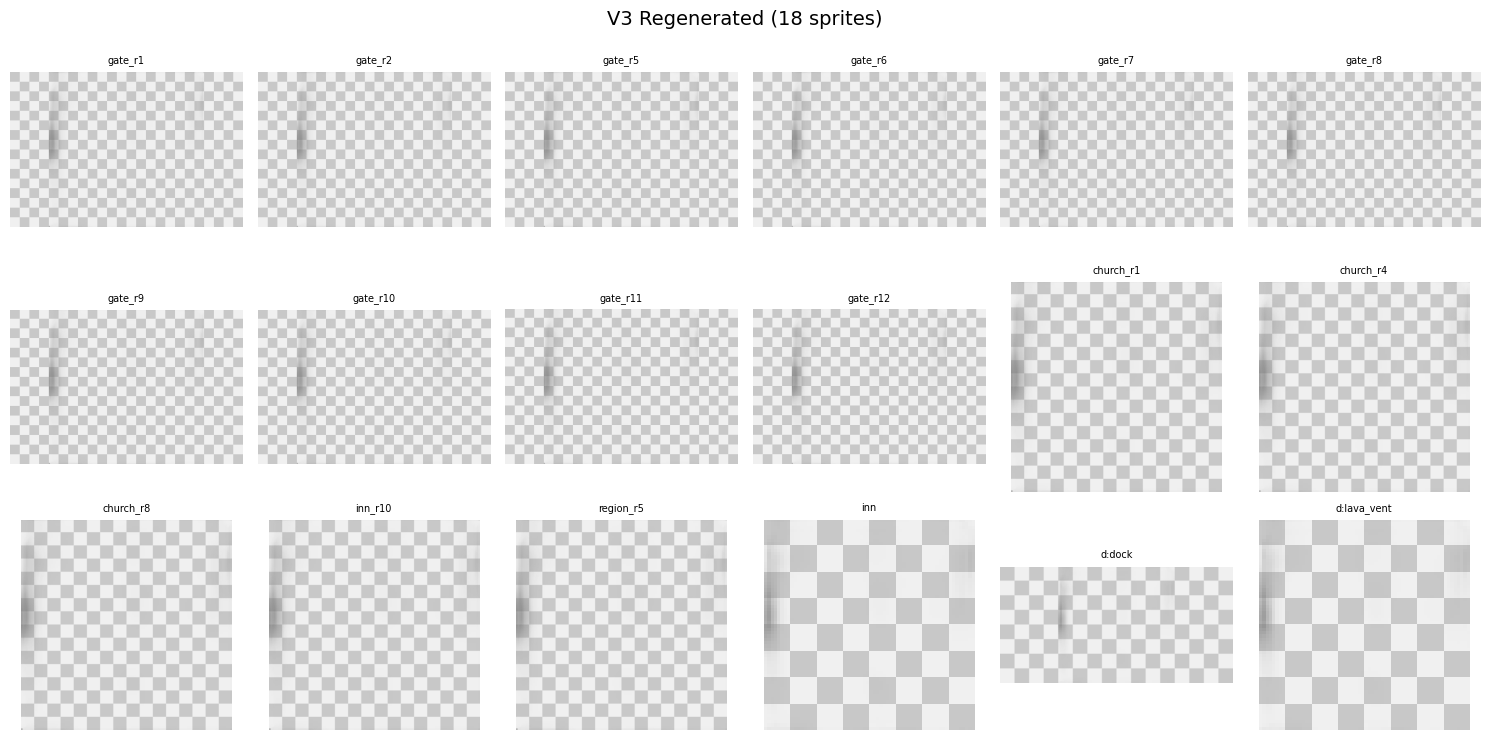

In [6]:
import matplotlib.pyplot as plt

# ─── Final quality scan of generated items ───
print('=== V3 Quality Scan ===')
all_ok = True
for entry in V3_ENTRIES:
    name = entry['name']
    out_dir = deco_dir if entry['type'] == 'deco' else bld_dir
    out_path = out_dir / f'{name}.png'
    if not out_path.exists():
        print(f'  MISSING: {name}')
        all_ok = False
        continue
    img = Image.open(out_path).convert('RGBA')
    passed, opaque_pct = quality_check(img, entry['min_opaque'])
    kb = out_path.stat().st_size / 1024
    status = 'OK' if passed else 'FAIL'
    flag = '✅' if passed else '❌'
    print(f'  {flag} {name:<25} opq={opaque_pct:>5.1%}  {kb:>5.0f}KB  {status}')
    if not passed:
        all_ok = False

if all_ok:
    print('\nAll V3 items pass quality check!')
else:
    print('\nSome items still failing — may need manual prompt tweaks.')

# ─── Preview grid ───
v3_pngs = []
for entry in V3_ENTRIES:
    out_dir_e = deco_dir if entry['type'] == 'deco' else bld_dir
    p = out_dir_e / f"{entry['name']}.png"
    if p.exists():
        v3_pngs.append(p)

if v3_pngs:
    cols = min(6, len(v3_pngs))
    rows = (len(v3_pngs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    axes = np.atleast_2d(axes)
    for ax in axes.flat:
        ax.axis('off')
    for i, png in enumerate(v3_pngs):
        ax = axes[i // cols][i % cols]
        img = Image.open(png)
        # Checkerboard bg for visibility
        w, h = img.size
        checker = np.zeros((h, w, 4), dtype=np.uint8)
        for y in range(h):
            for x in range(w):
                c = 200 if (x // 8 + y // 8) % 2 == 0 else 240
                checker[y, x] = [c, c, c, 255]
        bg = Image.fromarray(checker, 'RGBA')
        bg.paste(img, (0, 0), img)
        ax.imshow(bg)
        ax.set_title(png.stem.replace('bld_', '').replace('deco_', 'd:'), fontsize=7)
    plt.suptitle(f'V3 Regenerated ({len(v3_pngs)} sprites)', fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
import shutil

# ─── Generate manifest and zip ───
manifest = {}
for cat_name, cat_dir in [('buildings', bld_dir), ('decorations', deco_dir)]:
    if cat_dir.exists():
        keys = sorted(f.stem for f in cat_dir.glob('*.png') if not f.stem.startswith('_'))
        if keys:
            manifest[cat_name] = keys

manifest_path = OUTPUT_BASE / 'manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print('Manifest:')
for cat, keys in manifest.items():
    print(f'  {cat}: {len(keys)}')

zip_path = '/content/buildings_v3_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
print(f'\nZip: {os.path.getsize(zip_path + ".zip") / 1024 / 1024:.1f} MB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')

Manifest:
  buildings: 80
  decorations: 10
